In [1]:
import os
os.listdir()

['.config', 'sample_data']

In [2]:
import shutil
shutil.rmtree('sample_data')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1**. **Import and Explore**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

- Load both CSVs.
- Check for nulls, data types, and basic stats.

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Analyst Projects/Loan Default Risk Analysis/borrower_profiles.csv')
df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [6]:
df.isnull().sum()

,0
borrower_id,0
age,0
state,0
education_level,0
employment_status,0
years_employed,0
annual_income,0
credit_score,0
home_ownership,0
dependents,0


In [7]:
df.shape

(500, 11)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [8]:
df.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [9]:
df.dtypes

,0
borrower_id,object
age,int64
state,object
education_level,object
employment_status,object
years_employed,int64
annual_income,int64
credit_score,int64
home_ownership,object
dependents,int64


In [10]:
df.select_dtypes(include = 'number')

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
0,62,6,31020,596,1,892
1,24,4,40188,543,2,869
2,50,22,41014,611,0,1806
3,43,19,35036,701,2,928
4,46,18,44528,715,0,608
...,...,...,...,...,...,...
495,27,4,60337,661,0,2359
496,23,3,54617,773,3,1475
497,30,7,85000,845,3,1894
498,62,14,62749,811,1,1339


In [11]:
df.select_dtypes(include = 'object')

,borrower_id,state,education_level,employment_status,home_ownership
0,BRW-0001,CT,High School,Self-Employed,Rent
1,BRW-0002,CO,High School,Full-Time,Own
2,BRW-0003,NC,Bachelor,Contract,Mortgage
3,BRW-0004,TX,High School,Full-Time,Mortgage
4,BRW-0005,NY,High School,Full-Time,Own
...,...,...,...,...,...
495,BRW-0496,IL,Bachelor,Contract,Mortgage
496,BRW-0497,MO,High School,Full-Time,Rent
497,BRW-0498,CO,Doctorate,Self-Employed,Mortgage
498,BRW-0499,MA,Bachelor,Full-Time,Rent


In [12]:
dataset = pd.read_csv('/content/drive/MyDrive/Analyst Projects/Loan Default Risk Analysis/loan_applications.csv')
dataset.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [13]:
dataset.isnull().sum()

,0
loan_id,0
borrower_id,0
application_date,0
loan_purpose,0
loan_amount,0
term_months,0
interest_rate,0
monthly_payment,0
dti_ratio,0
loan_status,0


In [14]:
dataset.shape

(601, 12)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    object 
 1   borrower_id       601 non-null    object 
 2   application_date  601 non-null    object 
 3   loan_purpose      601 non-null    object 
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    object 
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 56.5+ KB


In [16]:
dataset.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [17]:
dataset.dtypes

,0
loan_id,object
borrower_id,object
application_date,object
loan_purpose,object
loan_amount,float64
term_months,int64
interest_rate,float64
monthly_payment,float64
dti_ratio,float64
loan_status,object


In [18]:
dataset.select_dtypes(include='number')

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
0,16100.0,36,13.05,542.86,55.5,0,0
1,5600.0,48,14.21,153.62,40.4,138,1
2,44700.0,36,12.37,1492.59,70.5,0,0
3,9200.0,48,11.18,238.58,59.8,34,1
4,11200.0,36,9.66,359.61,44.1,0,0
...,...,...,...,...,...,...,...
596,29100.0,36,7.38,903.59,52.3,31,1
597,4600.0,12,7.27,398.60,32.4,0,0
598,7800.0,60,9.86,165.19,28.8,0,0
599,26400.0,24,11.44,1235.85,73.2,15,0


In [19]:
dataset.select_dtypes(include='object')

,loan_id,borrower_id,application_date,loan_purpose,loan_status
0,LN-00001,BRW-0001,2024-01-08,Vacation,Paid Off
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,Default
2,LN-00003,BRW-0002,2025-06-28,Moving,Paid Off
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,Default
4,LN-00005,BRW-0004,2025-03-24,Moving,Current
...,...,...,...,...,...
596,LN-00597,BRW-0497,2025-02-06,Wedding,Default
597,LN-00598,BRW-0498,2024-04-19,Moving,Current
598,LN-00599,BRW-0499,2024-02-24,Education,Current
599,LN-00600,BRW-0500,2024-11-14,Medical Expenses,Late


In [20]:
dataset.select_dtypes(include='float')

,loan_amount,interest_rate,monthly_payment,dti_ratio
0,16100.0,13.05,542.86,55.5
1,5600.0,14.21,153.62,40.4
2,44700.0,12.37,1492.59,70.5
3,9200.0,11.18,238.58,59.8
4,11200.0,9.66,359.61,44.1
...,...,...,...,...
596,29100.0,7.38,903.59,52.3
597,4600.0,7.27,398.60,32.4
598,7800.0,9.86,165.19,28.8
599,26400.0,11.44,1235.85,73.2


- Join the two tables on borrower_id

In [21]:
df1 = pd.read_csv('/content/drive/MyDrive/Analyst Projects/Loan Default Risk Analysis/borrower_profiles.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Analyst Projects/Loan Default Risk Analysis/loan_applications.csv')
display(df1.head(),df2.head())

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [22]:
df3 = pd.merge(df1,df2,on='borrower_id')
df3.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


**2. Segment Analysis**

- Create credit score buckets and calculate default rates for each

In [31]:
credit_bins = [0,599,649,699,749,850]
credit_labels = ['300-599','600-649','650-699','700-749','750+']

df3['credit_score_bucket'] = pd.cut(df3['credit_score'],bins=credit_bins,labels=credit_labels)

credit_analysis = (
    df3.groupby('credit_score_bucket',observed=True)
    .agg(
        total_loans = ('loan_status','count'),
        defaults = ('defaulted', lambda x: (x == 1).sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
)

print("Credit Score Segment Analysis")
credit_analysis

Credit Score Segment Analysis


,total_loans,defaults,default_rate
credit_score_bucket,,,
300-599,116,57,49.14
600-649,93,27,29.03
650-699,75,21,28.00
700-749,86,14,16.28
750+,231,27,11.69


In [25]:
credit_analysis['default_rate']

,default_rate
credit_score_bucket,
300-599,49.14
600-649,29.03
650-699,28.00
700-749,16.28
750+,11.69


- Create DTI buckets and calculate default rates for each

In [30]:
dti_bins = [0, 15, 25, 35, 45, 100]
dti_labels = ['0-15%','16-25%','26-35%','36-45%','45%']

df3['dti_bucket'] = pd.cut(df3['dti_ratio'],bins=dti_bins,labels=dti_labels)

dti_analysis = (
    df3.groupby('dti_bucket',observed=True)
    .agg(
        total_loans = ('loan_status','count'),
        defaults = ('defaulted', lambda x: (x == 1).sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
)

print("DTI Segment Analysis")
dti_analysis

DTI Segment Analysis


,total_loans,defaults,default_rate
dti_bucket,,,
0-15%,23,4,17.39
16-25%,56,5,8.93
26-35%,102,13,12.75
36-45%,90,19,21.11
45%,308,97,31.49


- Calculate default rates for each employment status

In [29]:
employment_analysis = (
    df3.groupby('employment_status',observed=True)
    .agg(
        total_loans = ('loan_status','count'),
        defaults = ('defaulted', lambda x: (x == 1).sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
    .sort_values('default_rate',ascending=False)
)
print("Employment Status Segment Analysis")
employment_analysis

Employment Status Segment Analysis


,total_loans,defaults,default_rate
employment_status,,,
Part-Time,65,18,27.69
Self-Employed,105,26,24.76
Full-Time,305,73,23.93
Retired,60,14,23.33
Contract,66,15,22.73


- Calculate default rates for each loan purpose

In [32]:
loan_purpose_analysis = (
    df3.groupby('loan_purpose',observed=True)
    .agg(
        total_loans = ('loan_status','count'),
        defaults = ('defaulted', lambda x: (x == 1).sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
    .sort_values('default_rate',ascending=False)
)
print("Loan Purpose Segment Analysis")
loan_purpose_analysis

Loan Purpose Segment Analysis


,total_loans,defaults,default_rate
loan_purpose,,,
Wedding,56,18,32.14
Home Improvement,70,20,28.57
Auto Loan,59,16,27.12
Business Loan,58,14,24.14
Education,53,12,22.64
Vacation,62,14,22.58
Major Purchase,68,15,22.06
Debt Consolidation,51,11,21.57
Moving,56,12,21.43


**COMBINED SUMMARY OF SEGMENT ANALYSIS**

In [36]:
all_segments = {
    'Credit Score': credit_analysis,
    'DTI': dti_analysis,
    'Employment': employment_analysis,
    'Loan Purpose': loan_purpose_analysis
}

for segment_name, result in all_segments.items():
    print(f"{segment_name} Segment Analysis\n")
    print(result)
    print()

Credit Score Segment Analysis

                     total_loans  defaults  default_rate
credit_score_bucket                                     
300-599                      116        57         49.14
600-649                       93        27         29.03
650-699                       75        21         28.00
700-749                       86        14         16.28
750+                         231        27         11.69

DTI Segment Analysis

            total_loans  defaults  default_rate
dti_bucket                                     
0-15%                23         4         17.39
16-25%               56         5          8.93
26-35%              102        13         12.75
36-45%               90        19         21.11
45%                 308        97         31.49

Employment Segment Analysis

                   total_loans  defaults  default_rate
employment_status                                     
Part-Time                   65        18         27.69
Self-Employed   

**3. Correlation Analysis**

In [37]:
from scipy import stats

- Identify which numeric variables (credit score, DTI, income, loan amount, interest rate) have the strongest correlation with defaults.

In [38]:
numeric_vars = ['credit_score','dti_ratio','annual_income','loan_amount','interest_rate','defaulted']
corr_df3 = df3[numeric_vars].copy()

Pearson Correlation Matrix

In [39]:
corr_matrix = corr_df3.corr(method='pearson')
corr_matrix.round(3)

,credit_score,dti_ratio,annual_income,loan_amount,interest_rate,defaulted
credit_score,1.000,-0.121,0.110,-0.003,-0.755,-0.286
dti_ratio,-0.121,1.000,-0.206,0.399,0.104,0.192
annual_income,0.110,-0.206,1.000,0.273,-0.094,-0.082
loan_amount,-0.003,0.399,0.273,1.000,-0.003,0.018
interest_rate,-0.755,0.104,-0.094,-0.003,1.000,0.199
defaulted,-0.286,0.192,-0.082,0.018,0.199,1.000


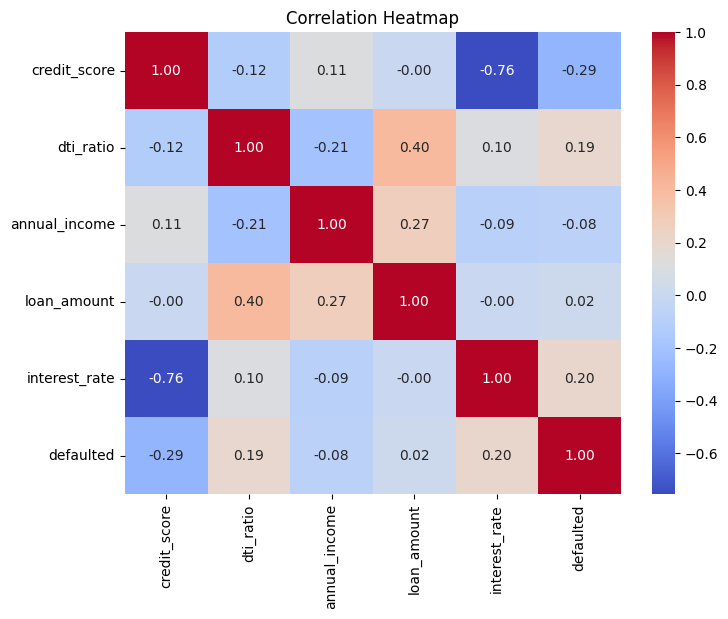

In [56]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# 4. Display
plt.title('Correlation Heatmap')
plt.show()

In [40]:
default_corr = (corr_matrix['defaulted']
                .drop('defaulted')
                .abs()
                .sort_values(ascending=False))
default_corr.round(3)

,defaulted
credit_score,0.286
interest_rate,0.199
dti_ratio,0.192
annual_income,0.082
loan_amount,0.018


Point-Biserial Correlation

In [41]:
results = {}
for var in numeric_vars:
  if var == 'defaulted':
    continue
  pbcorr_df3 = corr_df3[[var,'defaulted']].dropna()
  corr_val, p_val = stats.pointbiserialr(pbcorr_df3['defaulted'], pbcorr_df3[var])
  significant = "Yes" if p_val < 0.05 else "No"
  results[var] = {'correlation': corr_val.round(3), 'p_value': p_val, 'significant': significant}
results_df = pd.DataFrame(results).T

results_df

,correlation,p_value,significant
credit_score,-0.286,0.0,Yes
dti_ratio,0.192,0.000002,Yes
annual_income,-0.082,0.045685,Yes
loan_amount,0.018,0.657591,No
interest_rate,0.199,0.000001,Yes


**4. Visualization**

- Build charts showing default rate by credit score range

In [42]:
credit_bins   = [0, 599, 649, 699, 749, 850]
credit_labels = ['300–599', '600–649', '650–699', '700–749', '750+']
df3['credit_score_bucket'] = pd.cut(df3['credit_score'], bins=credit_bins, labels=credit_labels)



In [43]:
credit_summary = (df3.groupby('credit_score_bucket', observed=True)
                    .agg(total=('defaulted', 'count'),
                         defaults=('defaulted', 'sum'))
                    .assign(default_rate=lambda x: (x['defaults'] / x['total'] * 100).round(1))
                    .reset_index()
)

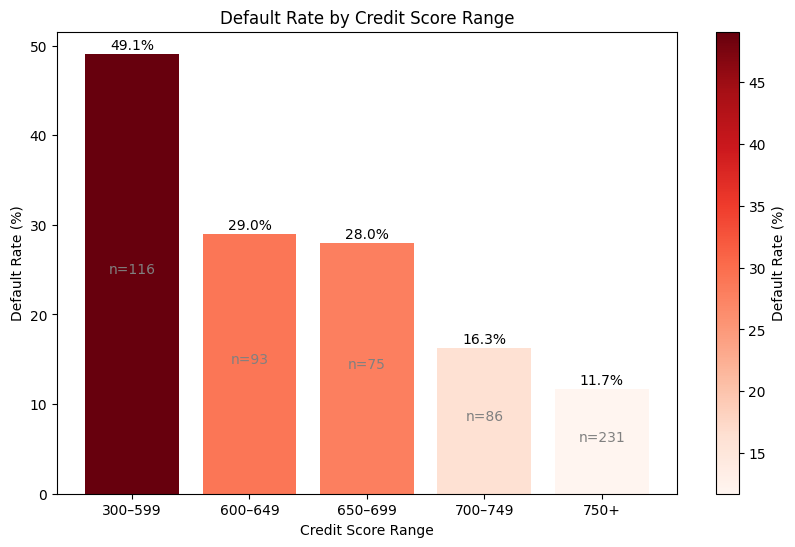

In [44]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

norm = plt.Normalize(
    credit_summary['default_rate'].min(),
    credit_summary['default_rate'].max()
)

# choose a colormap (red = high risk)
colors = plt.cm.Reds(norm(credit_summary['default_rate']))

bars = ax1.bar(
    credit_summary['credit_score_bucket'],
    credit_summary['default_rate'],
    color=colors
)

sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
plt.colorbar(sm, ax=ax1, label='Default Rate (%)')


for bar, rate, total in zip(bars, credit_summary['default_rate'], credit_summary['total']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{rate}%',
        ha='center'
    )
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'n={total}',
        ha='center',
        color='grey'
    )

ax1.set_title('Default Rate by Credit Score Range')
ax1.set_xlabel('Credit Score Range')
ax1.set_ylabel('Default Rate (%)')

plt.show()

- Build a scatter plot of DTI vs. default status, and a bar chart comparing loan purposes.

In [45]:
dti_bins = [0, 15, 25, 35, 45, 100]
dti_labels = ['0-15%','16-25%','26-35%','36-45%','45%']

df3['dti_bucket'] = pd.cut(df3['dti_ratio'],bins=dti_bins,labels=dti_labels)

In [46]:
dti_summary = (
    df3.groupby('dti_bucket',observed=True)
    .agg(
        total = ('loan_status','count'),
        defaults = ('loan_status', lambda x: (x == 'Default').sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total'] * 100).round(2))
    .reset_index()
)

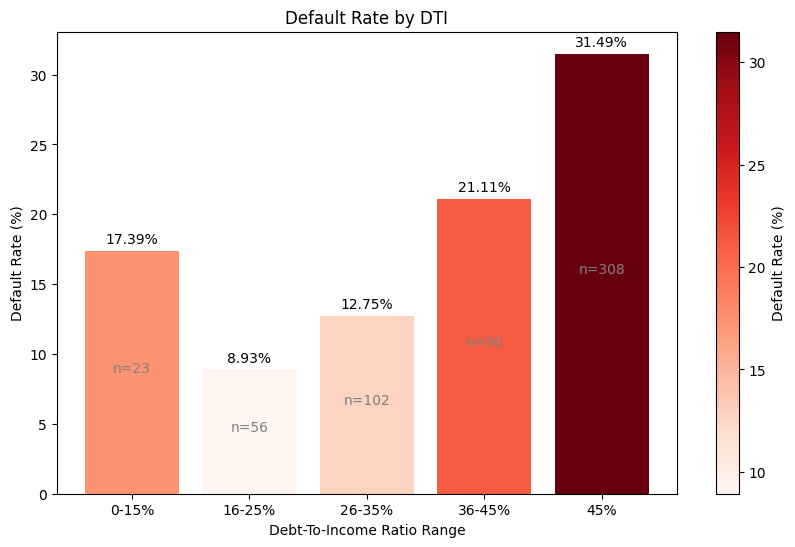

In [47]:
fig1, ax2 = plt.subplots(figsize=(10,6))

norm = plt.Normalize(
    dti_summary['default_rate'].min(),
    dti_summary['default_rate'].max()
)

# choose a colormap (red = high risk)
colors = plt.cm.Reds(norm(dti_summary['default_rate']))

bars = ax2.bar(
    dti_summary['dti_bucket'],
    dti_summary['default_rate'],
    color=colors
)

sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
plt.colorbar(sm, ax=ax2, label='Default Rate (%)')

for bar, rate, total in zip(bars, dti_summary['default_rate'], dti_summary['total']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{rate}%',
        ha='center'
    )
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'n={total}',
        ha='center',
        color='grey'
    )

ax2.set_title('Default Rate by DTI')
ax2.set_xlabel('Debt-To-Income Ratio Range')
ax2.set_ylabel('Default Rate (%)')

plt.show()

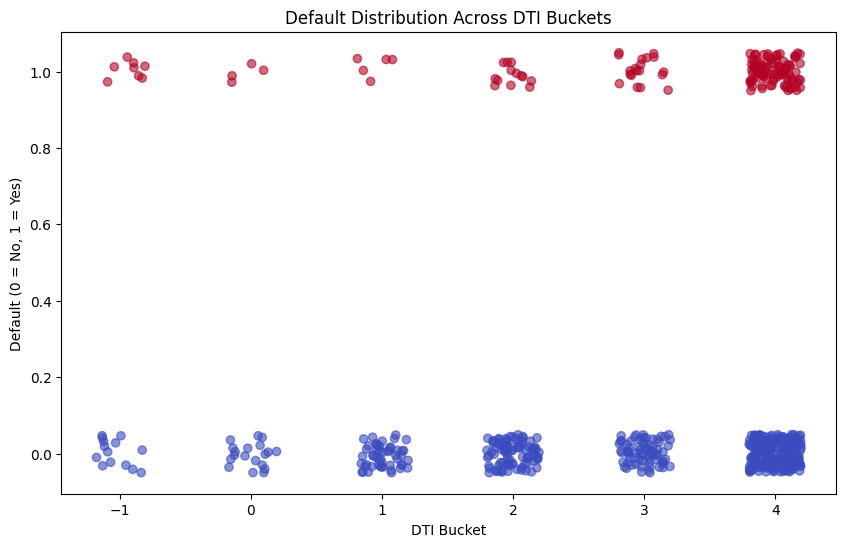

In [48]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df3['dti_bucket'].cat.codes + np.random.uniform(-0.2, 0.2, size=len(df3)),
    df3['defaulted'] + np.random.uniform(-0.05, 0.05, size=len(df3)),
    c=df3['defaulted'],
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel('DTI Bucket')
plt.ylabel('Default (0 = No, 1 = Yes)')
plt.title('Default Distribution Across DTI Buckets')

plt.show()

- Build a bar chart comparing loan purposes.

In [49]:
loan_purpose_summary = (
    df3.groupby('loan_purpose',observed=True)
    .agg(
        total = ('loan_status','count'),
        defaults = ('loan_status', lambda x: (x == 'Default').sum())
    )
    .assign(default_rate = lambda x: (x['defaults'] / x['total'] * 100).round(2))
    .reset_index()
)

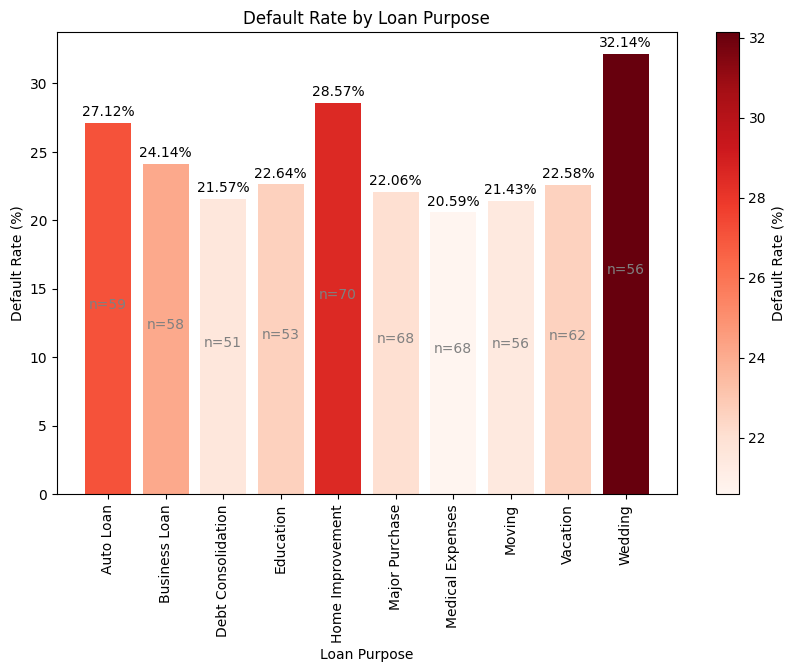

In [50]:
fig, ax3 = plt.subplots(figsize=(10,6))

norm = plt.Normalize(
    loan_purpose_summary['default_rate'].min(),
    loan_purpose_summary['default_rate'].max()
)

# choose a colormap (red = high risk)
colors = plt.cm.Reds(norm(loan_purpose_summary['default_rate']))

bars = ax3.bar(
    loan_purpose_summary['loan_purpose'],
    loan_purpose_summary['default_rate'],
    color=colors
)

sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
plt.colorbar(sm, ax=ax3, label='Default Rate (%)')


for bar, rate, total in zip(bars, loan_purpose_summary['default_rate'], loan_purpose_summary['total']):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{rate}%',
        ha='center'
    )
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'n={total}',
        ha='center',
        color='grey'
    )

ax3.set_title('Default Rate by Loan Purpose')
ax3.set_xlabel('Loan Purpose')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Default Rate (%)')

plt.show()

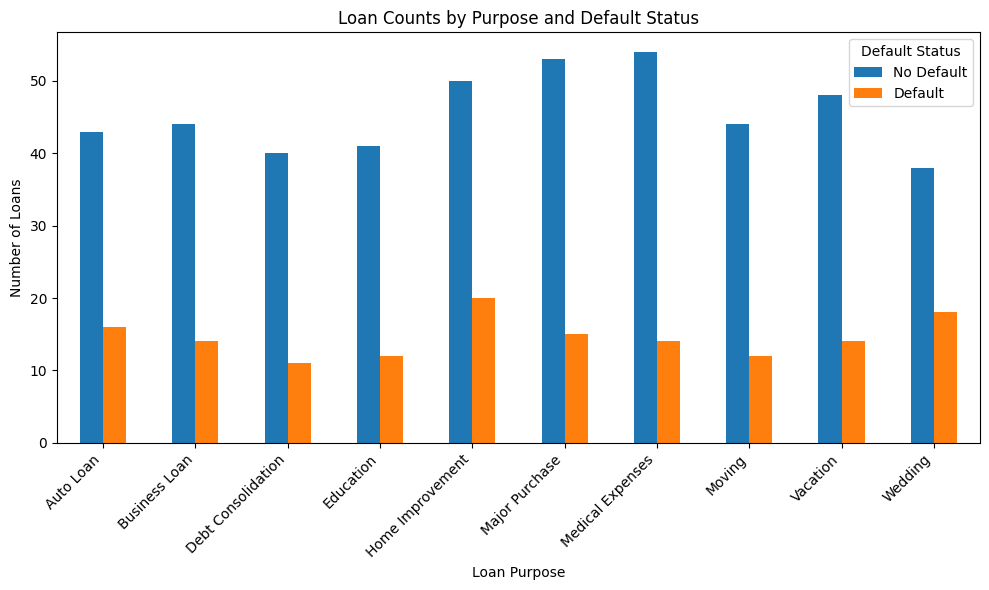

In [51]:
loan_purpose_counts = df3.groupby('loan_purpose')['defaulted'].value_counts().unstack()
loan_purpose_counts.plot(kind='bar', figsize = (10,6))

plt.title('Loan Counts by Purpose and Default Status')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha = 'right')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
plt.tight_layout()

Are borrowers with less than 2 years of employment significantly more likely to default?

In [52]:
less_than_2_years_employed = df3[df3['years_employed'] < 2]
total_loans_less_than_2_years = len(less_than_2_years_employed)
default_loans_less_than_2_years = less_than_2_years_employed['defaulted'].sum()
default_rate_less_than_2_years = ((default_loans_less_than_2_years / total_loans_less_than_2_years) * 100).round(2) if total_loans_less_than_2_years > 0 else 0

print(f"Default rate of borrowers with less than 2 years of employment: {default_rate_less_than_2_years}% (n = {total_loans_less_than_2_years})")

overall_default_rate = (df3['defaulted'].sum() / len(df3) * 100).round(2)
print(f"Overall default rate: {overall_default_rate}% (n = {len(df3)})")

Default rate of borrowers with less than 2 years of employment: 34.52% (n = 84)
Overall default rate: 24.29% (n = 601)


How do employment status and years employed affect default risk?

In [53]:
yrs_employed = df3.groupby(df3['years_employed'])['defaulted'].value_counts().unstack(fill_value = 0)
yrs_employed['default_rate'] = (yrs_employed[1] / (yrs_employed[0] + yrs_employed[1]) * 100).round(2)
yrs_employed.sort_values('default_rate',ascending=False)

defaulted,0,1,default_rate
years_employed,,,
6,12,15,55.56
23,1,1,50.00
35,1,1,50.00
34,4,3,42.86
1,27,18,40.00
25,5,3,37.50
17,10,6,37.50
15,10,5,33.33
32,4,2,33.33


With respect to loan purpose does the average loan amount differ significantly between defaulted and non-defaulted loans?

In [54]:
loan_purpose_avg = df3.groupby(['loan_purpose','defaulted'])['loan_amount'].mean().unstack(fill_value = 0)
loan_purpose_avg['difference'] = loan_purpose_avg[1] - loan_purpose_avg[0]
loan_purpose_avg.round(3).sort_values('difference', ascending = False)

defaulted,0,1,difference
loan_purpose,,,
Education,17114.634,29183.333,12068.699
Medical Expenses,21298.148,30421.429,9123.280
Debt Consolidation,21030.000,29036.364,8006.364
Auto Loan,18404.651,22643.750,4239.099
Moving,21115.909,21975.000,859.091
Vacation,24527.083,24307.143,-219.940
Wedding,22313.158,21005.556,-1307.602
Home Improvement,25110.000,19150.000,-5960.000
Business Loan,22479.545,16407.143,-6072.403
